# Sales_Forecasting & Demand_Prediction

## Data Loading 

## Objective
To build a complete end-to-end solution that predicts future sales using historical data
and creates an interactive dashboard for business decision-making. This project
integrates machine learning + analytics + visualization.

In [2]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Converting Order Date to Date-Time

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [4]:
df = df[["Order Date", "Sales", "Category", "Region"]]

In [5]:
df.head()

,Order Date,Sales,Category,Region
0,2017-11-08,261.9600,Furniture,South
1,2017-11-08,731.9400,Furniture,South
2,2017-06-12,14.6200,Office Supplies,West
3,2016-10-11,957.5775,Furniture,South
4,2016-10-11,22.3680,Office Supplies,South


In [6]:
df.isnull().sum()

Order Date    0
Sales         0
Category      0
Region        0
dtype: int64

## Creating Monthly Sales Time Series

In [7]:
# Set date as index
df.set_index("Order Date", inplace=True)

# Monthly total sales
monthly_sales = df.resample("M").sum()

monthly_sales.head()

C:\Users\ARGHYADIP GHOSH\AppData\Local\Temp\ipykernel_10964\1815360240.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M").sum()


,Sales,Category,Region
Order Date,,,
2015-01-31,14205.707,Office SuppliesOffice SuppliesOffice SuppliesO...,CentralCentralCentralCentralEastWestSouthSouth...
2015-02-28,4519.892,TechnologyOffice SuppliesOffice SuppliesTechno...,CentralWestSouthSouthWestWestWestWestWestSouth...
2015-03-31,55205.797,FurnitureTechnologyFurnitureOffice SuppliesOff...,WestEastCentralCentralCentralCentralCentralCen...
2015-04-30,27906.855,Office SuppliesOffice SuppliesOffice SuppliesO...,WestWestEastEastSouthSouthSouthCentralCentralS...
2015-05-31,23644.303,Office SuppliesTechnologyOffice SuppliesOffice...,EastSouthCentralEastEastCentralEastCentralCent...


## Saved Clean Data to monthly_sales.csv

In [8]:
monthly_sales.to_csv("monthly_sales.csv")

## Exploratory Data Analysis

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

monthly = pd.read_csv("monthly_sales.csv", index_col=0, parse_dates=True)

monthly.head()

,Sales,Category,Region
Order Date,,,
2015-01-31,14205.707,Office SuppliesOffice SuppliesOffice SuppliesO...,CentralCentralCentralCentralEastWestSouthSouth...
2015-02-28,4519.892,TechnologyOffice SuppliesOffice SuppliesTechno...,CentralWestSouthSouthWestWestWestWestWestSouth...
2015-03-31,55205.797,FurnitureTechnologyFurnitureOffice SuppliesOff...,WestEastCentralCentralCentralCentralCentralCen...
2015-04-30,27906.855,Office SuppliesOffice SuppliesOffice SuppliesO...,WestWestEastEastSouthSouthSouthCentralCentralS...
2015-05-31,23644.303,Office SuppliesTechnologyOffice SuppliesOffice...,EastSouthCentralEastEastCentralEastCentralCent...


## Sales Trend Over Time

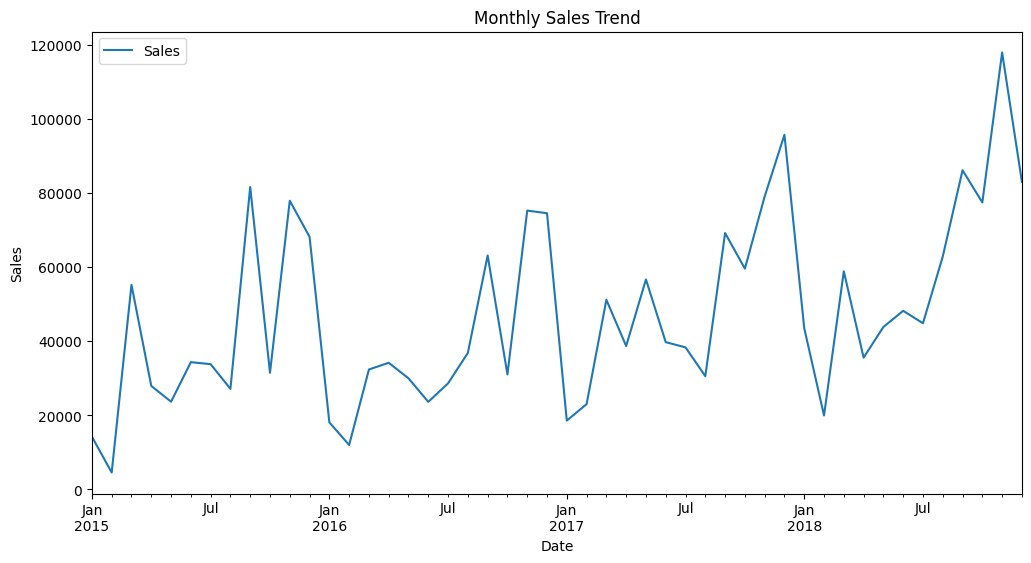

In [10]:
monthly.plot(figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.show()

## Seasonality in Monthly Pattern

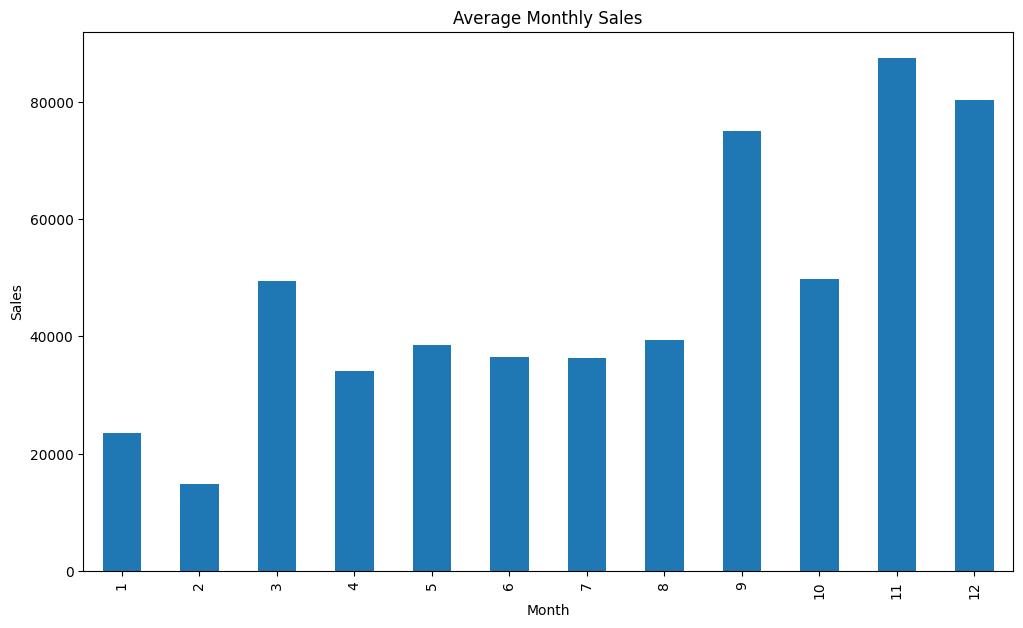

In [13]:
monthly["Month"] = monthly.index.month

seasonality = monthly.groupby("Month")["Sales"].mean()

seasonality.plot(kind="bar", figsize=(12,7))
plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.show()

## Category-wise Sales

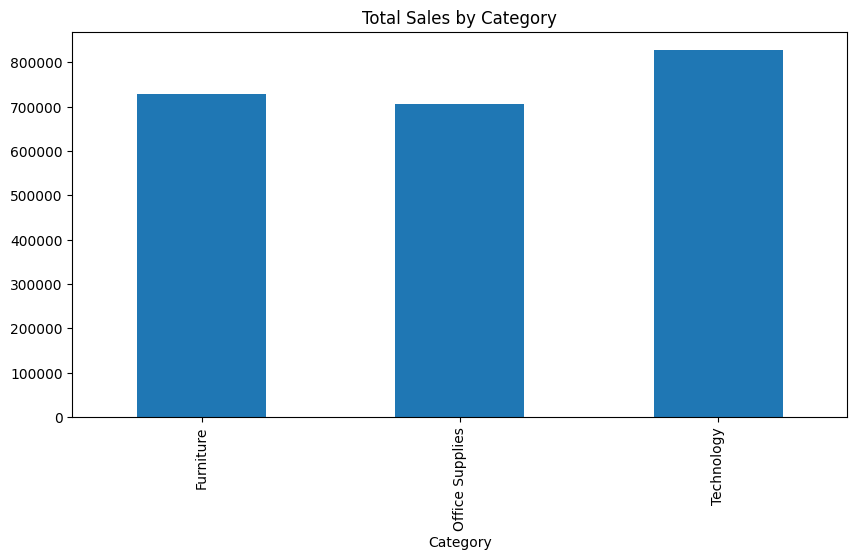

In [18]:
df = pd.read_csv("train.csv")

category_sales = df.groupby("Category")["Sales"].sum()
category_sales.plot(kind="bar", figsize=(10,5))
plt.title("Total Sales by Category")
plt.show()

## Region-wise Sales

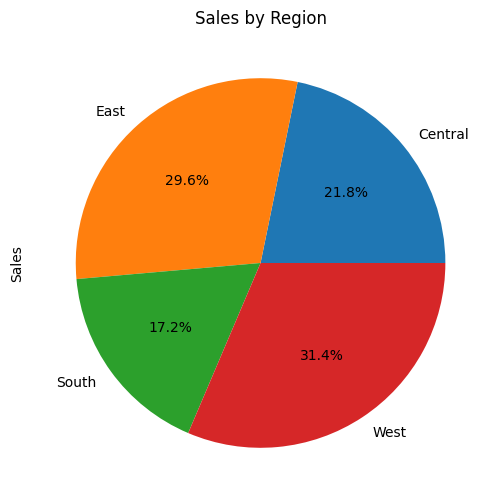

In [20]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sales by Region")
plt.show()

In [21]:
data = pd.read_csv("monthly_sales.csv", index_col=0, parse_dates=True)
data.head()

,Sales,Category,Region
Order Date,,,
2015-01-31,14205.707,Office SuppliesOffice SuppliesOffice SuppliesO...,CentralCentralCentralCentralEastWestSouthSouth...
2015-02-28,4519.892,TechnologyOffice SuppliesOffice SuppliesTechno...,CentralWestSouthSouthWestWestWestWestWestSouth...
2015-03-31,55205.797,FurnitureTechnologyFurnitureOffice SuppliesOff...,WestEastCentralCentralCentralCentralCentralCen...
2015-04-30,27906.855,Office SuppliesOffice SuppliesOffice SuppliesO...,WestWestEastEastSouthSouthSouthCentralCentralS...
2015-05-31,23644.303,Office SuppliesTechnologyOffice SuppliesOffice...,EastSouthCentralEastEastCentralEastCentralCent...


## Preparing Data for Prophet

In [22]:
df = data.reset_index()

# Keep only Date and Sales
df = df[["Order Date", "Sales"]] if "Order Date" in df.columns else df.iloc[:, [0, 1]]

df.columns = ["ds", "y"]

df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [24]:
from prophet import Prophet

model = Prophet()
model.fit(df)

Importing plotly failed. Interactive plots will not work.
20:24:27 - cmdstanpy - INFO - Chain [1] start processing
20:24:28 - cmdstanpy - INFO - Chain [1] done processing


## Generating Sales Forecast

In [25]:
# Create future dates (next 60 months)
future = model.make_future_dataframe(periods=60, freq="M")


forecast = model.predict(future)

forecast.head()

C:\Users\ARGHYADIP GHOSH\AppData\Roaming\Python\Python314\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,5237.532403,23321.748809,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-7560.524112,11721.671567,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,43008.992125,61284.843428,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,11600.237584,29879.727292,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,13126.056206,31534.749974,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


## Forecast Plotting

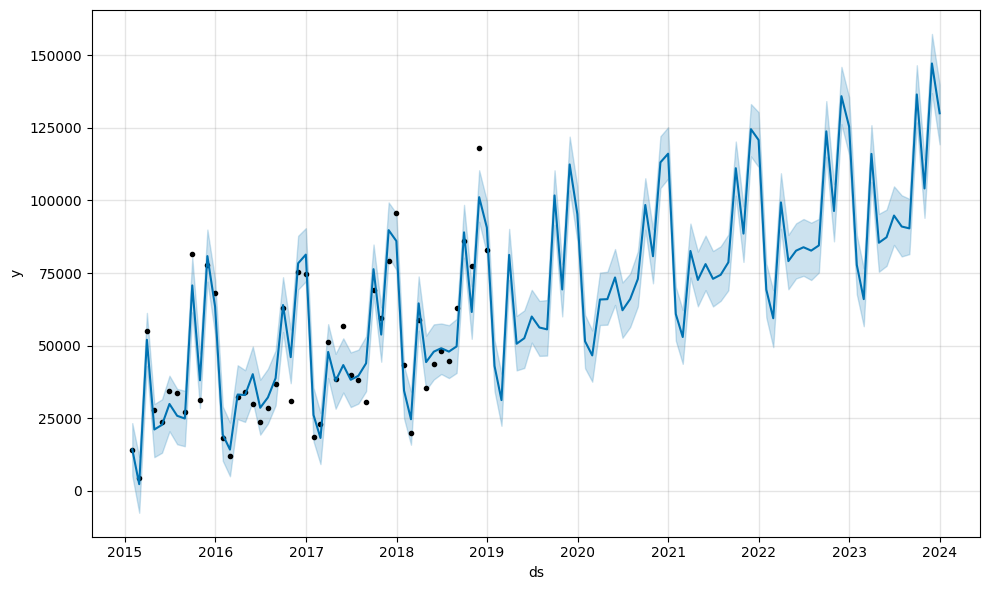

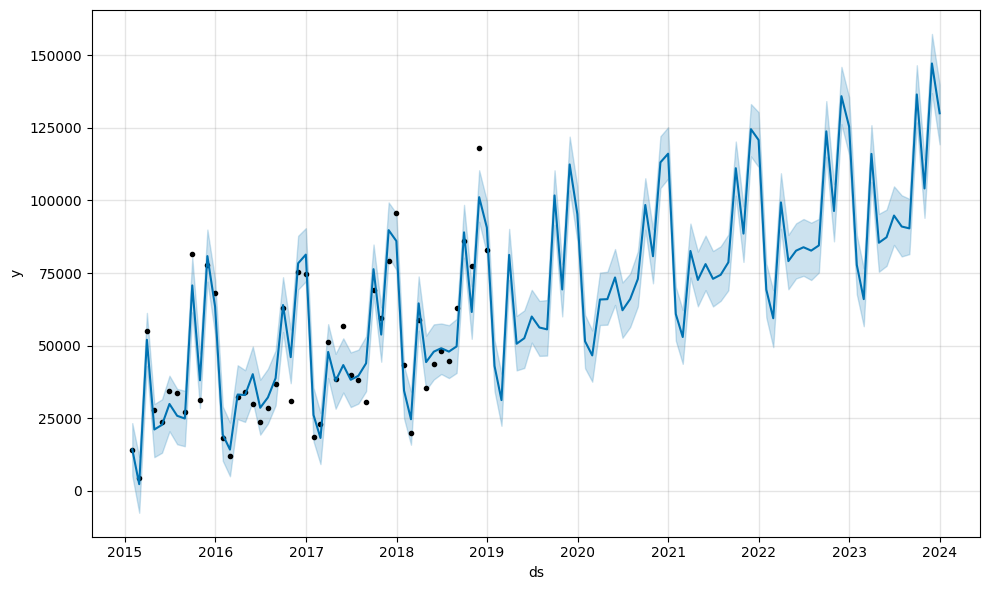

In [26]:
model.plot(forecast)

In [37]:

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv("forecast.csv", index=False)

## Evaluation of Model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge forecast with actuals
actual = df.copy()
predicted = forecast[["ds", "yhat"]]

merged = actual.merge(predicted, on="ds", how="inner")

# Calculate metrics
mae = mean_absolute_error(merged["y"], merged["yhat"])
rmse = np.sqrt(mean_squared_error(merged["y"], merged["yhat"]))
mape = np.mean(np.abs((merged["y"] - merged["yhat"]) / merged["y"])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 5770.415946784901
RMSE: 7272.004220576394
MAPE: 14.482661931976429 %


## Future Sales (Next 60 Months)

In [28]:
future_forecast = forecast[forecast["ds"] > df["ds"].max()]

future_forecast[["ds", "yhat"]].head()

,ds,yhat
48,2019-01-31,42990.532201
49,2019-02-28,31248.159920
50,2019-03-31,81267.007771
51,2019-04-30,50658.420139
52,2019-05-31,52555.922385


## Growth [Expected]

In [29]:
current_sales = df["y"].tail(12).mean()
future_sales = future_forecast["yhat"].head(12).mean()

growth = ((future_sales - current_sales) / current_sales) * 100
print("Expected annual growth:", growth, "%")

Expected annual growth: 12.092417903056917 %


## High Demand Months (Seasonality)

In [30]:
future_forecast["Month"] = future_forecast["ds"].dt.month
peak_months = future_forecast.groupby("Month")["yhat"].mean().sort_values(ascending=False)

peak_months.head()

C:\Users\ARGHYADIP GHOSH\AppData\Local\Temp\ipykernel_10964\1249172211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_forecast["Month"] = future_forecast["ds"].dt.month


Month
11    126640.073286
12    117534.202649
9     114322.834517
3      89032.738241
10     87846.183106
Name: yhat, dtype: float64

## Low Demand Months

In [42]:
peak_months.tail()

Month
6    74789.551721
7    74090.613246
4    70769.928862
1    60487.785239
2    51263.920757
Name: yhat, dtype: float64

## Performance of Category

In [31]:
raw = pd.read_csv("train.csv")

category_perf = raw.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_perf

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64